# Notebook precedente


In [2]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import dill

# Import di LIME per l'interpretazione dei modelli
from lime.lime_tabular import LimeTabularExplainer

# Rimozione dei warnings per rendere l'output più pulito
import warnings
warnings.filterwarnings('ignore')

SEED = 2025

In [12]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import dill

# Import di LIME per l'interpretazione dei modelli
from lime.lime_tabular import LimeTabularExplainer

# Rimozione dei warnings per rendere l'output più pulito
import warnings
warnings.filterwarnings('ignore')

SEED = 2025

# Caricamento e preparazione dei dati
data = load_breast_cancer()
x = data.data
y = data.target

# Divisione dei dati in set di addestramento e test
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=SEED)

# Normalizzazione dei dati
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

# Creazione e addestramento del MLP
mlp = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(xtrain, ytrain)

# Valutazione dell'accuratezza del modello
train_accuracy = accuracy_score(ytrain, mlp.predict(xtrain))
test_accuracy = accuracy_score(ytest, mlp.predict(xtest))
print(f"Accuratezza train: {train_accuracy:.4f}, Accuratezza test: {test_accuracy:.4f}")

# Creazione dell'explainer LIME specificando tutti i parametri richiesti
explainer = LimeTabularExplainer(xtrain,
                                 mode='classification',
                                 training_labels=ytrain,
                                 feature_names=data.feature_names,
                                 class_names=data.target_names,
                                 discretize_continuous=True)

# Scelta di un'istanza da spiegare
instance_idx = 25  # Modifica questo indice per esplorare altre predizioni
instance = xtest[instance_idx]

# Generazione della spiegazione con LIME
exp = explainer.explain_instance(data_row=instance,
                                 predict_fn=mlp.predict_proba,
                                 num_features=10,  # Numero massimo di caratteristiche da visualizzare nella spiegazione
                                 top_labels=1)

!mkdir _aux

# Salviamo tutto per analisi successive

#datapoints preprocessati
np.save('_aux/xtest_prepr',xtest)

#modello addesterato
dill.dump(mlp,open('_aux/MLP_model.pkl','wb'))

#explainer
dill.dump(explainer,open('_aux/lime.pkl','wb'))

#singola spiegazione
dill.dump(exp,open('_aux/lime_single_'+str(instance_idx)+'.pkl','wb'))

Accuratezza train: 0.9956, Accuratezza test: 0.9737


Sottodirectory o file _aux gi� esistente.


# Import modello addestrato

In [7]:


#datapoints preprocessati
xtest = np.load('_aux/xtest_prepr.npy')

#modello addesterato
mlp = dill.load(open('_aux/MLP_model.pkl','rb'))

#explainer
explainer = dill.load(open('_aux/lime.pkl','rb'))

#singola spiegazione
exp = dill.load(open('_aux/lime_single_25.pkl','rb'))

In [13]:
exp.as_list()

[('worst texture <= -0.77', 0.17296567821717138),
 ('worst concavity <= -0.72', 0.16748836960754065),
 ('worst smoothness > 0.56', -0.1457287798647217),
 ('compactness error <= -0.70', -0.1144537555026066),
 ('-0.63 < worst area <= -0.32', 0.09679177556762604),
 ('-0.73 < mean concavity <= -0.34', 0.07522357569332754),
 ('mean texture <= -0.71', 0.07504151559632942),
 ('-0.58 < fractal dimension error <= -0.21', -0.06743012552266041),
 ('-0.72 < mean concave points <= -0.39', 0.05748498835985371),
 ('-0.66 < mean area <= -0.28', 0.054802999592687654)]

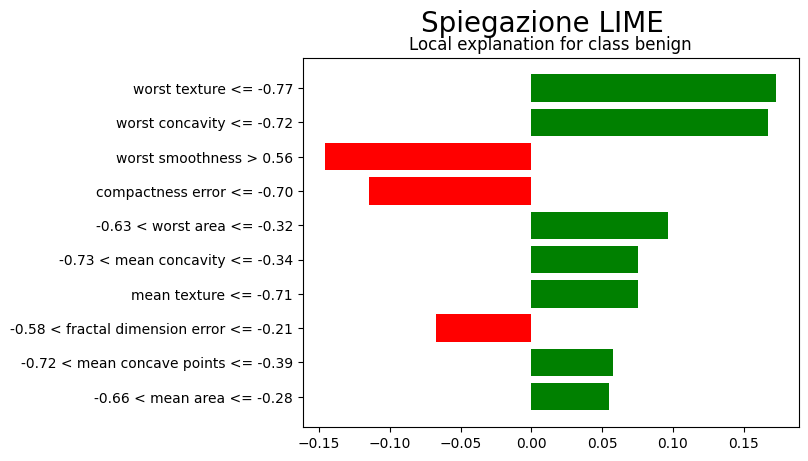

In [14]:
# Visualizzazione della spiegazione come figura matplotlib
fig = exp.as_pyplot_figure()
fig.suptitle('Spiegazione LIME', fontsize=20)
plt.show()

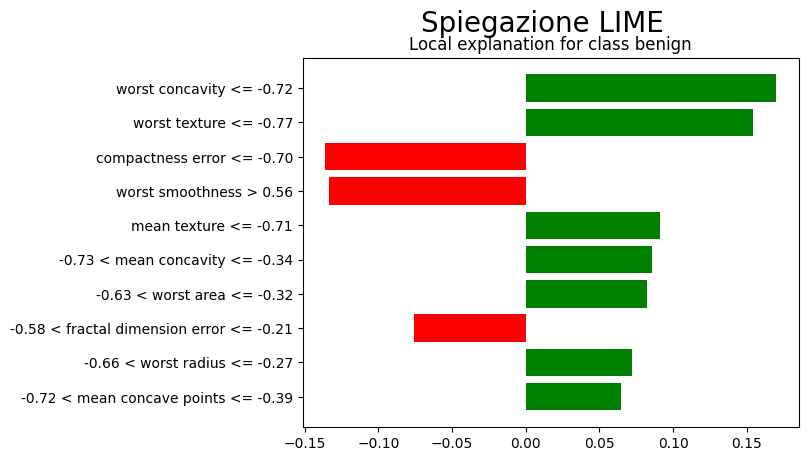

In [38]:
exp25a = explainer.explain_instance(data_row=xtest[25], predict_fn=mlp.predict_proba,
                                 num_features=10, top_labels=1)
fig = exp25a.as_pyplot_figure()
fig.suptitle('Spiegazione LIME', fontsize=20);

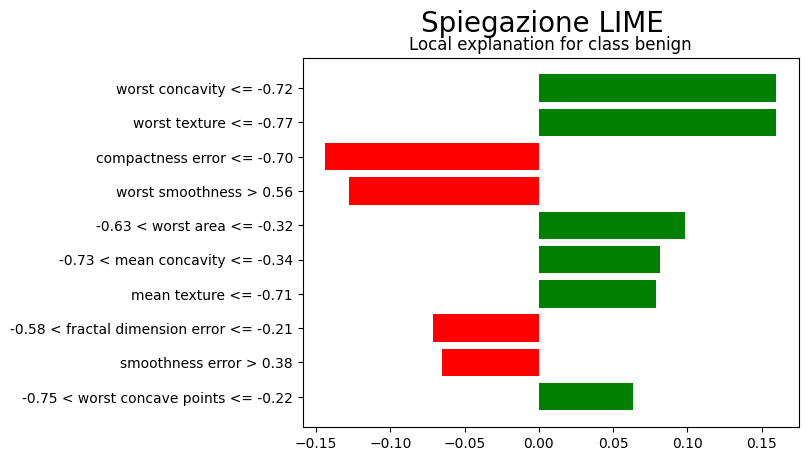

In [39]:
exp25b = explainer.explain_instance(data_row=xtest[25], predict_fn=mlp.predict_proba,
                                 num_features=10, top_labels=1)
fig = exp25b.as_pyplot_figure()
fig.suptitle('Spiegazione LIME', fontsize=20);

In [41]:
explainer.explain_instance(data_row=xtest[25], predict_fn=mlp.predict_proba,
                                 num_features=10, top_labels=1).as_map()

{1: [(21, 0.16754116310176734),
  (26, 0.1672793456069401),
  (24, -0.12957430641053647),
  (15, -0.12178033544860178),
  (23, 0.0925378925642628),
  (6, 0.08055064808494979),
  (7, 0.06710167297481003),
  (22, 0.06557664372922738),
  (8, 0.06526293777817184),
  (20, 0.06209922390607168)]}

In [42]:
do_lime = lambda x : explainer.explain_instance(data_row=xtest[x], predict_fn=mlp.predict_proba,
                                 num_features=10, top_labels=1).as_map()

In [43]:
all_exp = [do_lime(i) for i in range(xtest.shape[0])]

In [44]:
1 in all_exp[0]

True

In [45]:
aggregated_scores = {i:[] for i in range(xtest.shape[1])}
for exp in all_exp:
    data = exp[0] if 0 in exp else exp[1]
    for fnum,score in data:
        aggregated_scores[fnum] = aggregated_scores[fnum]+[score]

In [46]:
all_exp[0]

{1: [(21, 0.16631478053384663),
  (23, 0.09692622567292754),
  (26, 0.09170197562301192),
  (6, 0.07544756769153727),
  (20, 0.05678111408651565),
  (1, 0.053053177999479194),
  (24, 0.05012169216163177),
  (3, 0.045382911006665284),
  (22, 0.04317904496212314),
  (18, -0.040880942372815254)]}

In [47]:
fnames = load_breast_cancer()['feature_names']

In [48]:
vals_to_plot = [np.sum(np.abs(v)) for v in aggregated_scores.values()]

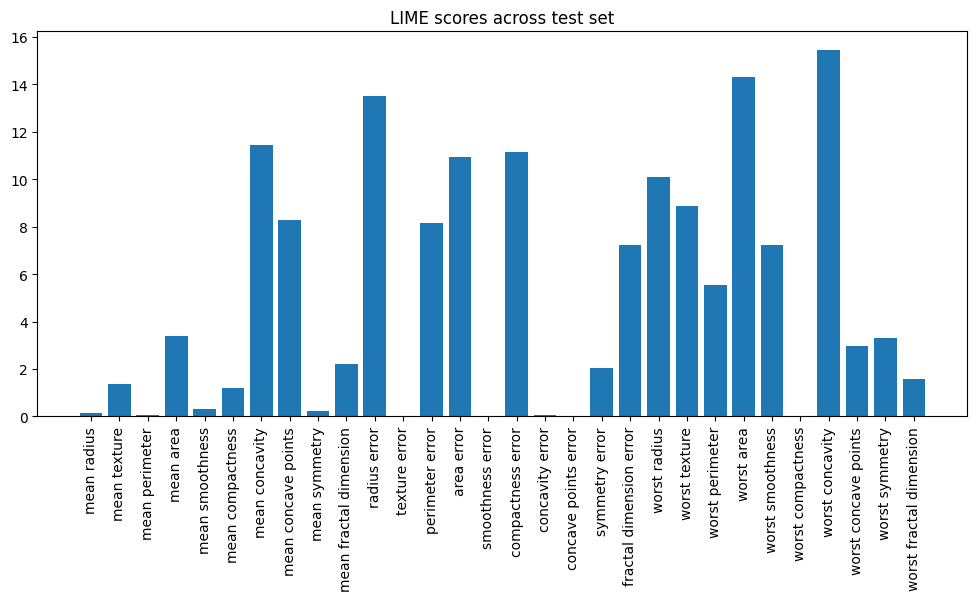

In [49]:
plt.figure(figsize=(12,5))
plt.bar(fnames,vals_to_plot)
plt.xticks(rotation=90)
plt.title('LIME scores across test set');